In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from math import e
from scipy.optimize import minimize
from IPython.display import clear_output
from scipy import optimize
from scipy.stats import norm
import pickle
from scipy import integrate
from scipy import stats

In [2]:
data = pd.read_excel('data.ods')

In [3]:
data['T (ºC)'] = data['T_R_K'] - 273

In [4]:
data = data.loc[((data['CINÉTICA'] == 1) | (data['DESATIVAÇÃO'] == 1))]
# data = data.loc[((data['F_C2H6_s_mol_s'] != 0) & (data['F_C3H8_s_mol_s'] != 0))]

In [5]:
data[['F_Olef_C2_e', 'F_Olef_C3_e', 
   'F_Olef_C7_e', 'F_Olef_C8_e', 'F_Olef_C9_e', 'F_Olef_C10_e', 'F_Olef_C11_e', 
   'F_Olef_C12_e', 'F_Olef_C13_e', 'F_Olef_C14_e', 'F_Olef_C15_e', 
     'F_Olef_C16_e', 'F_Olef_C17_e', 'F_Olef_C18_e',

    
    'F_C1_e', 'F_C2_e', 'F_C3_e', 'F_C7_e', 'F_C8_e', 'F_C9_e', 'F_C10_e', 'F_C11_e', 
      'F_C12_e', 'F_C13_e', 'F_C14_e', 'F_C15_e', 'F_C16_e', 'F_C17_e', 'F_C18_e',
      'F_C19_e', 'F_C20_e', 'F_C21_e', 'F_C22_e', 'F_C23_e', 'F_C24_e', 'F_C25_e', 
      'F_C26_e', 'F_C27_e', 'F_C28_e', 'F_C29_e', 'F_C30_e', 'F_C31_e', 'F_C32_e', 
      'F_C33_e', 'F_C34_e', 'F_C35_e', 'F_C36_e']] = 0

/tmp/ipykernel_11087/1583070280.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['F_Olef_C2_e', 'F_Olef_C3_e',


In [6]:
data.columns

Index(['t_h', 'CINÉTICA', 'PLOT', 'DESATIVAÇÃO', 'BM', 'VALIDATION',
       'P_abs_Pa', 'T_R_K', 'F_H2_e_mol_s', 'F_CO_e_mol_s',
       ...
       'F_C27_e', 'F_C28_e', 'F_C29_e', 'F_C30_e', 'F_C31_e', 'F_C32_e',
       'F_C33_e', 'F_C34_e', 'F_C35_e', 'F_C36_e'],
      dtype='str', length=117)

In [7]:
# doing raw mass balance to check errors

In [8]:
data['$m_{gas,in}$ (g/s)'] = data['F_H2_e_mol_s']*2 + data['F_CO_e_mol_s']*(12+16)

/tmp/ipykernel_11087/3025465940.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{gas,in}$ (g/s)'] = data['F_H2_e_mol_s']*2 + data['F_CO_e_mol_s']*(12+16)


In [9]:
data['$m_{gas,out}$ (g/s)'] = (data['F_H2_s_mol_s']*2 + data['F_CO_s_mol_s']*(12+16)
                              + data['F_CO2_s_mol_s']*44 + data['F_CH4_s_mol_s']*16
                              + data['F_C2H6_s_mol_s']*((2*12)+6) + data['F_C3H8_s_mol_s']*((3*12)+8)
                              )

/tmp/ipykernel_11087/3263301007.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{gas,out}$ (g/s)'] = (data['F_H2_s_mol_s']*2 + data['F_CO_s_mol_s']*(12+16)


In [10]:
data['$m_{liq,out}$ (g/s)'] = data['$m_{gas,in}$ (g/s)'] - data['$m_{gas,out}$ (g/s)']

/tmp/ipykernel_11087/238849197.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{liq,out}$ (g/s)'] = data['$m_{gas,in}$ (g/s)'] - data['$m_{gas,out}$ (g/s)']


In [11]:
data['$m_{in}$ (g/s)'] = data['$m_{gas,in}$ (g/s)']

/tmp/ipykernel_11087/812820910.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{in}$ (g/s)'] = data['$m_{gas,in}$ (g/s)']


In [12]:
data['t_s'] = data['t_h']*3600

/tmp/ipykernel_11087/1787854520.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['t_s'] = data['t_h']*3600


In [13]:
data['$m_{in,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,in}$ (g/s)'], data['t_s'], initial = 0)

/tmp/ipykernel_11087/2251079583.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{in,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,in}$ (g/s)'], data['t_s'], initial = 0)


In [14]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data['m_SEP_acum (g)']
                              )

/tmp/ipykernel_11087/3054802661.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'],


In [15]:
data['MB_error_perc'] = 100*(data['$m_{in,cumul}$ (g)'] - 
                             data['$m_{out,cumul}$ (g)']) / data['$m_{in,cumul}$ (g)'].iloc[-1]

/tmp/ipykernel_11087/1906948692.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['MB_error_perc'] = 100*(data['$m_{in,cumul}$ (g)'] -


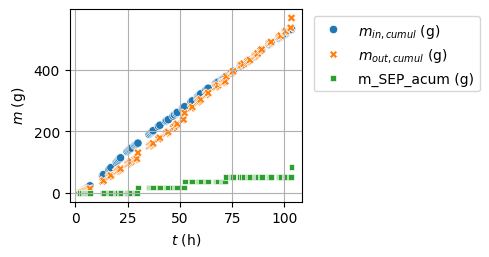

In [16]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'value',
             data=data[['t_h',
                        '$m_{in,cumul}$ (g)', 
                        '$m_{out,cumul}$ (g)',
                        'm_SEP_acum (g)',
                       ]].melt(id_vars = 't_h'), 
             hue = 'variable',
             style = 'variable',
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,10)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$m$ (g)')
fig_name = 'MB_cumul.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

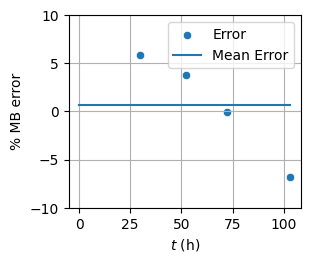

In [17]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'MB_error_perc',
             data=data.loc[data['LIQ_SAMPLE'] == 1],
             label = 'Error',
             ax = ax)

plt.grid('both')
plt.plot(np.linspace(0, data['t_h'].iloc[-1], 2), 
         (data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean(), 
          data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()), 
         label = 'Mean Error')
plt.ylim(-10,10)
# plt.xlim(0,80)
plt.legend()
plt.xlabel('$t$ (h)')
plt.ylabel('% MB error')
fig_name = 'MB_error.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [18]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()

np.float64(0.6936100673689993)

In [19]:
# now closing the mass balance using the integral mass balance to get the aprox liquid % in the outlet

In [20]:
data['$m_{total}$ (g/s)'] = data['$m_{in}$ (g/s)']

/tmp/ipykernel_11087/339318926.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{total}$ (g/s)'] = data['$m_{in}$ (g/s)']


In [21]:
data['mass_frac_liq'] = data['m_SEP_acum (g)']/data['$m_{in,cumul}$ (g)']

/tmp/ipykernel_11087/7219844.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['mass_frac_liq'] = data['m_SEP_acum (g)']/data['$m_{in,cumul}$ (g)']


In [22]:
data['$m_{liq,out}$ (g/s)'] = data['$m_{total}$ (g/s)']*data['mass_frac_liq'].iloc[-1]

In [23]:
data['$m_{gas,out}$ (g/s)'] = data['$m_{total}$ (g/s)'] - data['$m_{liq,out}$ (g/s)']

In [24]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data['m_SEP_acum (g)']
                              )

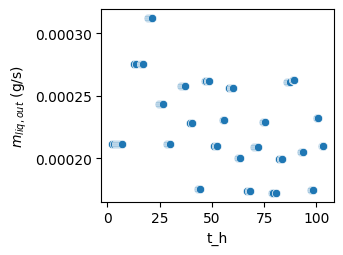

In [25]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = '$m_{liq,out}$ (g/s)',
             data=data,
             ax = ax)
plt.show()

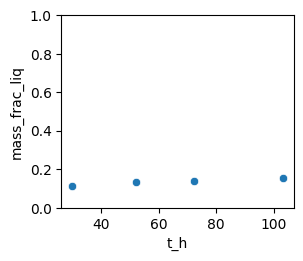

In [26]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'mass_frac_liq',
             data=data.loc[data['LIQ_SAMPLE'] == 1], 
             ax = ax)
plt.ylim(0,1)
plt.show()

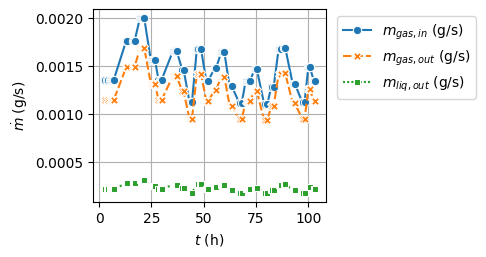

In [27]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x='t_h', y = 'value',
             data=data[['t_h',
                        'T_R_K',
                        '$m_{gas,in}$ (g/s)', 
                        '$m_{gas,out}$ (g/s)', 
                        '$m_{liq,out}$ (g/s)',
#                         '$m_{out}$ (g/s)',
#                         '$m_{in}$ (g/s)'
                       ]].melt(id_vars = ['t_h', 'T_R_K']), 
             hue = 'variable',
             style = 'variable',
#              size = 'T_R_K',
             markers = True,
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$\dot{m}$ (g/s)')
fig_name = 'MB.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [28]:
# recalculating gas outlet molar flow rates on reconciled data
data['F_gas_out (mol/s)'] = (data['F_H2_s_mol_s'] + data['F_CO_s_mol_s'] + data['F_CH4_s_mol_s']
                            + data['F_CO2_s_mol_s'] + data['F_C2H4_s_mol_s']
                             + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s']
                            )
data['y_H2_out'] = data['F_H2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO_out'] = data['F_CO_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CH4_out'] = data['F_CH4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO2_out'] = data['F_CO2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H4_out'] = data['F_C2H4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H6_out'] = data['F_C2H6_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C3H8_out'] = data['F_C3H8_s_mol_s']/data['F_gas_out (mol/s)']
data['MM_mean_gas'] = (data['y_H2_out']*2 + data['y_CO_out']*(12+16) + data['y_CH4_out']*16
                  + data['y_CO2_out']*44 + data['y_C2H6_out']*((2*12)+6) + data['y_C3H8_out']*((3*12)+8))
data['F_gas_out (mol/s)'] = data['$m_{gas,out}$ (g/s)']/data['MM_mean_gas']
data['F_H2_s_mol_s'] = data['y_H2_out']*data['F_gas_out (mol/s)']
data['F_CO_s_mol_s'] = data['y_CO_out']*data['F_gas_out (mol/s)']
data['F_CH4_s_mol_s'] = data['y_CH4_out']*data['F_gas_out (mol/s)']
data['F_CO2_s_mol_s'] = data['y_CO2_out']*data['F_gas_out (mol/s)']
data['F_C2H4_s_mol_s'] = data['y_C2H4_out']*data['F_gas_out (mol/s)']
data['F_C2H6_s_mol_s'] = data['y_C2H6_out']*data['F_gas_out (mol/s)']
data['F_C3H8_s_mol_s'] = data['y_C3H8_out']*data['F_gas_out (mol/s)']

/tmp/ipykernel_11087/547437140.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['F_gas_out (mol/s)'] = (data['F_H2_s_mol_s'] + data['F_CO_s_mol_s'] + data['F_CH4_s_mol_s']
/tmp/ipykernel_11087/547437140.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['y_H2_out'] = data['F_H2_s_mol_s']/data['F_gas_out (mol/s)']
/tmp/ipykernel_11087/547437140.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

In [29]:
data['$m_{liq,out}$ (g/s)'].mean()

np.float64(0.0002286347908447934)

In [30]:
# using oxygen elemental balance to correct water flow and get a better estimation of liquid hydrocarbon flow
data['F_H2O_s_mol_s'] = data['F_CO_e_mol_s'] - data['F_CO_s_mol_s'] - 2*data['F_CO2_s_mol_s']
data['$m_{H_2O,out}$ (g/s)'] = data['F_H2O_s_mol_s']*18

/tmp/ipykernel_11087/2706203512.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{H_2O,out}$ (g/s)'] = data['F_H2O_s_mol_s']*18


In [31]:
# fração de cera no produto líquido medida na balanca
# antes da correção pelo BM da água
data['frac_cera'].mean()

np.float64(0.37332344497837544)

In [32]:
# m C5+ out before H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)']*data['frac_cera']
data['$m_{C5+,out}$ (g/s)'].mean()

/tmp/ipykernel_11087/92138361.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)']*data['frac_cera']


np.float64(8.245802165965239e-05)

In [33]:
# m C5+ out after H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] - data['$m_{H_2O,out}$ (g/s)']
data['$m_{C5+,out}$ (g/s)'].mean()

np.float64(9.104547185185921e-05)

In [34]:
data['$m_{H_2O,out}$ (g/s)'].mean()

np.float64(0.00013758931899293423)

In [35]:
# fração de cera no produto líquido depois da correção pelo BM da água
data['frac_cera'] = data['$m_{C5+,out}$ (g/s)']/data['$m_{liq,out}$ (g/s)']
data['frac_cera'].mean()

np.float64(0.3973587393552895)

In [36]:
data[['F_C7', 'F_C8', 'F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
     'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[['w_C7', 'w_C8',
       'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13', 'w_C14', 'w_C15', 'w_C16',
       'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21', 'w_C22', 'w_C23', 'w_C24',
       'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29', 'w_C30', 'w_C31', 'w_C32',
       'w_C33', 'w_C34', 'w_C35', 'w_C36',
        'w_C7_olef', 'w_C8_olef',
       'w_C9_olef', 'w_C10_olef', 'w_C11_olef', 'w_C12_olef', 'w_C13_olef',
       'w_C14_olef', 'w_C15_olef', 'w_C16_olef', 'w_C17_olef', 'w_C18_olef'       
               ]].multiply(
    data['$m_{C5+,out}$ (g/s)'], axis = 'index')

# molar masses of liquid hydrocarbons
MM_PARAFIN = [n*12+2*n+2 for n in range(7,37)]
MM_OLEF = [n*12+2*n for n in range(7,19)]
MM = np.concat((MM_PARAFIN, MM_OLEF))

# to remove Performance Warning
# PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 
# `frame.insert` many times, which has poor performance.  Consider joining all columns 
# at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
data = data.copy()

# F = mass flow/molar mass
data[['F_C7', 'F_C8', 'F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[['F_C7', 'F_C8', 'F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
                                 ]].divide(MM, axis = 1)
data = data.copy()

/tmp/ipykernel_11087/769333031.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['F_C7', 'F_C8', 'F_C9', 'F_C10',


In [37]:
data['T_R_C'] = data['T_R_K'] - 273.15
data['$H_2/CO$'] = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
data['F_C1_C3_exp'] = (data['F_CH4_s_mol_s'] + data['F_C2H4_s_mol_s'] 
                       + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s'])
data['F_C5+_exp'] = data[['F_C7', 'F_C8', 'F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
       ]].sum(axis=1)
# data['alpha'] = (
#         (2.48e-15*data['P_abs_Pa']**2 - 1.19e-8*data['P_abs_Pa'] + 0.01597)*data['T_R_K'] +
#         (-1.5397e-12*data['P_abs_Pa']**2 + 6.8763e-6*data['P_abs_Pa'] - 7.7249)*(data['F_H2_e_mol_s']/data['F_CO_e_mol_s'])
#         )

In [38]:
# recalculating X on reconciled data
data['X_CO'] = (data['F_CO_e_mol_s'] - data['F_CO_s_mol_s']) / data['F_CO_e_mol_s']
data['X_H2'] = (data['F_H2_e_mol_s'] - data['F_H2_s_mol_s']) / data['F_H2_e_mol_s']

In [39]:
# calculating the alphas

In [40]:
data_ASF_F = pd.DataFrame()
data_ASF_F['F_C1'] = data['F_CH4_s_mol_s']
data_ASF_F['F_C2'] = data['F_C2H6_s_mol_s'] + data['F_C2H4_s_mol_s']
data_ASF_F['F_C3'] = data['F_C3H8_s_mol_s']
data_ASF_F['F_C7'] = data['F_C7'] + data['F_Olef_C7']
data_ASF_F['F_C8'] = data['F_C8'] + data['F_Olef_C8']
data_ASF_F['F_C9'] = data['F_C9'] + data['F_Olef_C9']
data_ASF_F['F_C10'] = data['F_C10'] + data['F_Olef_C10']
data_ASF_F['F_C11'] = data['F_C11'] + data['F_Olef_C11']
data_ASF_F['F_C12'] = data['F_C12'] + data['F_Olef_C12']
data_ASF_F['F_C13'] = data['F_C13'] + data['F_Olef_C13']
data_ASF_F['F_C14'] = data['F_C14'] + data['F_Olef_C14']
data_ASF_F['F_C15'] = data['F_C15'] + data['F_Olef_C15']
data_ASF_F['F_C16'] = data['F_C16'] + data['F_Olef_C16']
data_ASF_F['F_C17'] = data['F_C17'] + data['F_Olef_C17']
data_ASF_F['F_C18'] = data['F_C18'] + data['F_Olef_C18']
data_ASF_F['F_C19'] = data['F_C19']
data_ASF_F['F_C20'] = data['F_C20']
data_ASF_F['F_C21'] = data['F_C21']
data_ASF_F['F_C22'] = data['F_C22']
data_ASF_F['F_C23'] = data['F_C23']
data_ASF_F['F_C24'] = data['F_C24']
data_ASF_F['F_C25'] = data['F_C25']
data_ASF_F['F_C26'] = data['F_C26']
data_ASF_F['F_C27'] = data['F_C27']
data_ASF_F['F_C28'] = data['F_C28']
data_ASF_F['F_C29'] = data['F_C29']
data_ASF_F['F_C30'] = data['F_C30']
data_ASF_F['F_C31'] = data['F_C31']
data_ASF_F['F_C32'] = data['F_C32']
data_ASF_F['F_C33'] = data['F_C33']
data_ASF_F['F_C34'] = data['F_C34']
data_ASF_F['F_C35'] = data['F_C35']

# ignore PerformanceWarning: DataFrame is highly fragmented.  
# This is usually the result of calling `frame.insert` many times, which has poor performance.  
# Consider joining all columns at once using pd.concat(axis=1) instead. 
# To get a de-fragmented frame, use `newframe = frame.copy()`
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

data_ASF_F[['y1', 'y2', 'y3', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
                                  'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
                                  'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33',
                                   'y34', 'y35']] = data_ASF_F.div(data_ASF_F.sum(axis=1), axis=0)

In [41]:
data['OL_P_2'] = data['F_C2H4_s_mol_s']/data['F_C2H6_s_mol_s']
data['OL_P_7'] = data['F_Olef_C7']/data['F_C7']
data['OL_P_8'] = data['F_Olef_C8']/data['F_C8']
data['OL_P_9'] = data['F_Olef_C9']/data['F_C9']
data['OL_P_10'] = data['F_Olef_C10']/data['F_C10']
data['OL_P_11'] = data['F_Olef_C11']/data['F_C11']
data['OL_P_12'] = data['F_Olef_C12']/data['F_C12']
data['OL_P_13'] = data['F_Olef_C13']/data['F_C13']
data['OL_P_14'] = data['F_Olef_C14']/data['F_C14']
data['OL_P_15'] = data['F_Olef_C15']/data['F_C15']
data['OL_P_16'] = data['F_Olef_C16']/data['F_C16']
data['OL_P_17'] = data['F_Olef_C17']/data['F_C17']
data['OL_P_18'] = data['F_Olef_C18']/data['F_C18']

In [42]:
def SSR(params, y_exp):
    ssr = 0
    alpha = params[0]
    K_C2 = params[1]
    K_C3 = params[2]
#     print(alpha)
#     clear_output(wait=True)
    n = np.concat(([1,2,3],list(range(7,36))))
    for i in range(len(y_exp)):
        y_n_model = (1-alpha)*alpha**(n[i]-1 + K_C2*(n[i] == 2) + K_C3*(n[i] == 3))
        ssr = ssr + (y_exp[i] - y_n_model)**2
#     print(ssr)
    return ssr

In [43]:
data['alpha'] = 0.8 # initial estimate
data['K_C2'] = 5.0 # initial estimate
data['K_C3'] = 5.0 # initial estimate

bnds = ((0, 1), (None, None), (None, None))

for i in data_ASF_F.index:
    y_exp = data_ASF_F[['y1', 'y2', 'y3', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
                                  'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
                                  'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33',
                                   'y34', 'y35']].loc[i].values
    minimum = minimize(SSR, data[['alpha', 'K_C2', 'K_C3']].loc[i], method = 'Nelder-Mead',
                               bounds = bnds,
    #                            options={'maxfev':max_fev}, 
                               args = (y_exp))
    data.loc[i ,'alpha'] = minimum.x[0]
    data.loc[i ,'K_C2'] = minimum.x[1]
    data.loc[i ,'K_C3'] = minimum.x[2]

In [44]:
# save reconciled data
with open('reconciled_data.pkl', 'wb') as f:
    pickle.dump(data, f)

In [45]:
data.to_excel('reconciled_data.ods')

In [46]:
# plot alphas

In [47]:
data['P (bar)'] = data['P_abs_Pa']/1e5

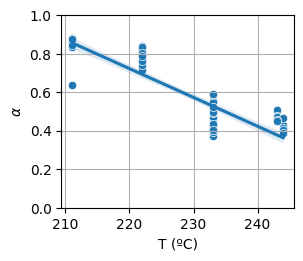

In [48]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] < 1.6e6)],
#             ax = ax, label = '15 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 1.6) & 
#                                               (data['P_abs_Pa'] < 2e6)],
#             ax = ax, label = '17.5 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2e6) & 
#                                               (data['P_abs_Pa'] < 2.2e6)],
#             ax = ax, label = '20 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2.2) & 
#                                               (data['P_abs_Pa'] < 2.5e6)],
#             ax = ax, label = '22.5 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2.5e6)],
#             ax = ax, label = '25 bar')
sns.regplot(x='T_R_C', y='alpha',
             data=data, scatter = False,
            ax = ax)
sns.scatterplot(x='T_R_C', y='alpha',
             data=data,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel(r'$\alpha$')
plt.xlabel('T (ºC)')
plt.ylim(0,1)
fig_name = 'alpha_vs_T.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

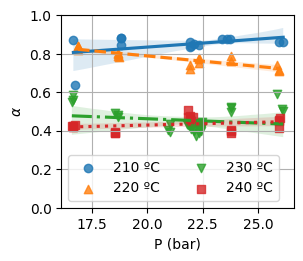

In [49]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] < (219+273))],
           label = '210 ºC', marker = 'o', line_kws = {'linestyle': '-'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (219+273)) & 
                                              (data['T_R_K'] < (229+273))],
           label = '220 ºC', marker = '^', line_kws = {'linestyle': '--'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (229+273)) & 
                                              (data['T_R_K'] < (239+273))],
           label = '230 ºC', marker = 'v', line_kws = {'linestyle': '-.'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (239+273)) & 
                                              (data['T_R_K'] < (249+273))],
           label = '240 ºC', marker = 's', 
           line_kws = {'linestyle': ':'})

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.legend(ncols = 2)
plt.ylim(0,1)
plt.ylabel(r'$\alpha$')
plt.xlabel('P (bar)')
fig_name = 'alpha_vs_P.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

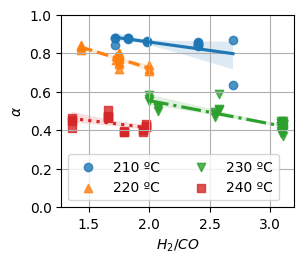

In [50]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] < (219+273))],
           label = '210 ºC', marker = 'o', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (219+273)) & 
                                              (data['T_R_K'] < (229+273))],
           label = '220 ºC', marker = '^', line_kws = {'linestyle': '--'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (229+273)) & 
                                              (data['T_R_K'] < (239+273))],
           label = '230 ºC', marker = 'v', line_kws = {'linestyle': '-.'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (239+273)) & 
                                              (data['T_R_K'] < (249+273))],
           label = '240 ºC', marker = 's', line_kws = {'linestyle': ':'})

plt.grid('both')
plt.legend(ncols = 2)
plt.ylabel(r'$\alpha$')
plt.ylim(0,1)
fig_name = 'alpha_vs_H2_CO.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

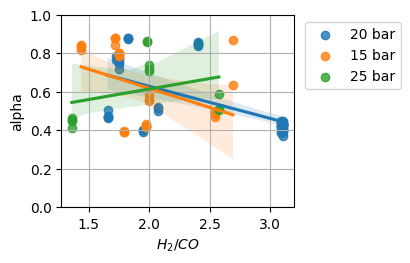

In [51]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] > 2e6) & 
                                              (data['P_abs_Pa'] < 2.5e6)],
            ax = ax, label = '20 bar')
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] < 2e6)],
            ax = ax, label = '15 bar')
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] > 2.5e6)],
            ax = ax, label = '25 bar')

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

In [52]:
# alpha regressions

In [53]:
def alphas(model_n, data, beta):
    T = data['T_R_K']
    P = data['P_abs_Pa']
    H2_CO = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
    match model_n:
        case 'model_1':
            return beta[0] + beta[1]*T + beta[2]*H2_CO + beta[3]*P + beta[4]*P**2
        case 'model_2':
            return beta[0] + beta[1]*T + beta[2]*H2_CO
        case 'model_3':
            return 1/(1 + e**-(beta[0] + beta[1]*T + beta[2]*H2_CO))
        case 'model_4':
            return 1/(1 + e**-(beta[0] + beta[1]*T))
        case 'model_5':
            return 1/(1 + e**-(beta[0] + beta[1]*T + beta[2]*H2_CO) + beta[3]*P + beta[4]*P**2)
        case 'model_6':
            return beta[0]*e**(-beta[1]*T -beta[2]*H2_CO)

In [54]:
def SSR_alpha_fit(beta, data, model_n):
    print(beta)
    clear_output(wait=True)
    ssr = 0
    alpha_model = alphas(model_n, data, beta)
    ssr = (data['alpha'] - alpha_model).pow(2).sum().sum()
    print(ssr)
    return ssr

In [55]:
def neg_logLik(beta, data, model_n):
    print(beta)
    clear_output(wait=True)
    alpha_model = alphas(model_n, data, beta)
    residuals = data['alpha'] - alpha_model
    # drop column if all NA
    residuals.dropna(how = 'all', inplace = True)
    residuals_flat = pd.DataFrame()
    residuals_flat['residuals_flat'] = residuals.values.flatten()
    neg_logLik = -norm.logpdf(residuals_flat,
                             residuals_flat.describe().loc['mean'],
                             residuals_flat.describe().loc['std']).sum()
    print(neg_logLik)
    return neg_logLik

In [56]:
minimums_alpha = pd.DataFrame(columns = ['model','fun','params', 'aic', 'nfev',
                                               'success', 'message'])

In [57]:
beta_model_1 = [1, 1e-3, 1e-1, 1e-5, 1e-10]

minimum_model_1 = minimize(SSR_alpha_fit, beta_model_1, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_1'))
beta = minimum_model_1.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_1') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[0] = ['model_1', minimum_model_1.fun, minimum_model_1.x, aic,
                           minimum_model_1.nfev, minimum_model_1.success, minimum_model_1.message]

-5.385557916332566


In [58]:
beta_model_2 = [1, 1e-3, 1e-1]

minimum_model_2 = minimize(SSR_alpha_fit, beta_model_2, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_2'))
beta = minimum_model_2.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_2') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[1] = ['model_2', minimum_model_2.fun, minimum_model_2.x, aic,
                           minimum_model_2.nfev, minimum_model_2.success, minimum_model_2.message]

-173.61366870430146


In [59]:
beta_model_3 = [1, 1e-3, 1e-1]

minimum_model_3 = minimize(SSR_alpha_fit, beta_model_3, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_3'))
beta = minimum_model_3.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_3') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[2] = ['model_3', minimum_model_3.fun, minimum_model_3.x, aic,
                           minimum_model_3.nfev, minimum_model_3.success, minimum_model_3.message]

-177.25279467659567


In [60]:
beta_model_4 = [1, 1e-3]

minimum_model_4 = minimize(SSR_alpha_fit, beta_model_4, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_4'))
beta = minimum_model_4.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_4') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[3] = ['model_4', minimum_model_4.fun, minimum_model_4.x, aic,
                           minimum_model_4.nfev, minimum_model_4.success, minimum_model_4.message]

-93.56468575494605


In [61]:
beta_model_5 = [1, 1e-3, 1e-1, 1e-5, 1e-10]

minimum_model_5 = minimize(SSR_alpha_fit, beta_model_5, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_5'))
beta = minimum_model_5.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_5') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[4] = ['model_5', minimum_model_5.fun, minimum_model_5.x, aic,
                           minimum_model_5.nfev, minimum_model_5.success, minimum_model_5.message]

-24.976037402982634


In [62]:
beta_model_6 = [1, 1e-3, 1e-1]

minimum_model_6 = minimize(SSR_alpha_fit, beta_model_6, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data, 'model_6'))
beta = minimum_model_6.x
K = len(beta) + 1
N = len(data)
aic = 2*K + 2*neg_logLik(beta, data, 'model_6') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[5] = ['model_6', minimum_model_6.fun, minimum_model_6.x, aic,
                           minimum_model_6.nfev, minimum_model_6.success, minimum_model_6.message]

-120.19956361117563


In [63]:
minimums_alpha['rel_lik'] = e**((minimums_alpha['aic'].min()-minimums_alpha['aic'])/2)


In [64]:
minimums_alpha

,model,fun,params,aic,nfev,success,message,rel_lik
0,model_1,4.616664,"[1.8160646645567131, 0.0024792353408806694, 0....",2.253274,369,True,Optimization terminated successfully.,2.351681e-76
1,model_2,0.105322,"[8.177837750916119, -0.014549648354617176, -0....",-338.751147,303,True,Optimization terminated successfully.,2.627530e-02
2,model_3,0.097081,"[36.14991390855849, -0.06859762217417498, -0.5...",-346.029399,266,True,Optimization terminated successfully.,1.000000e+00
3,model_4,0.638624,"[34.24916108966731, -0.06743437418982087]",-180.847019,128,True,Optimization terminated successfully.,1.352390e-36
4,model_5,2.972603,"[3.2890172343397444, 0.0002665347077838658, 0....",-36.927685,309,True,Optimization terminated successfully.,7.575574e-68
5,model_6,0.353501,"[2657.5323937953094, 0.015871560023218073, 0.2...",-231.922937,600,False,Maximum number of function evaluations has bee...,1.667618e-25


In [65]:
minimum_model_3.x

array([36.14991391, -0.06859762, -0.56477343])

In [66]:
# save best alpha model params
with open('alpha_params.pkl', 'wb') as f:
    pickle.dump(minimum_model_3.x, f)

In [67]:
data['alpha_model_1'] = alphas('model_1', data, minimum_model_1.x)
data['alpha_model_2'] = alphas('model_2', data, minimum_model_2.x)
data['alpha_model_3'] = alphas('model_3', data, minimum_model_3.x)
data['alpha_model_4'] = alphas('model_4', data, minimum_model_4.x)
data['alpha_model_5'] = alphas('model_5', data, minimum_model_5.x)
data['alpha_model_6'] = alphas('model_6', data, minimum_model_6.x)

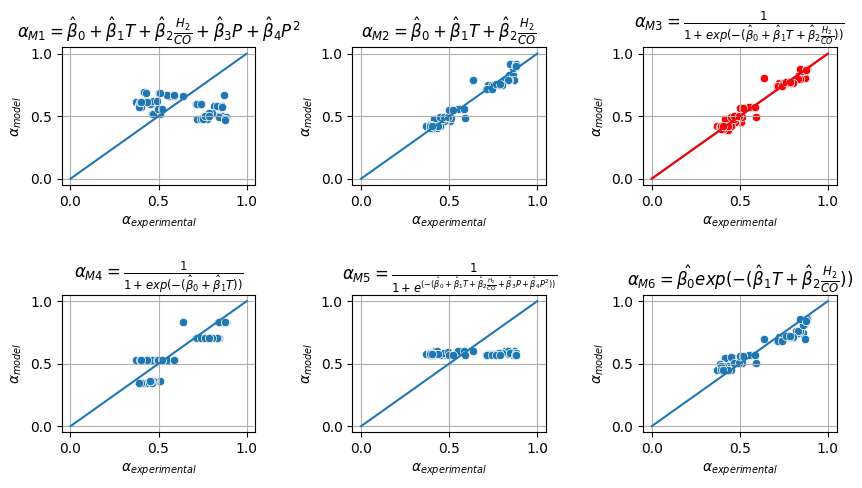

In [68]:
fig, ax = plt.subplots(2,3,figsize=(10,5))
plt.subplots_adjust(hspace=0.8, wspace = 0.5)
sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_1", 
                ax = ax[0,0],
)
ax[0,0].set_title(r'$\alpha_{M1} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO} + \hat{\beta}_3 P + \hat{\beta}_4 P^2$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_2", 
                ax = ax[0,1],
)
ax[0,1].set_title(r'$\alpha_{M2} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_3", 
                color = 'red',
                ax = ax[0,2],
)
ax[0,2].set_title(r'$\alpha_{M3} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_4", 
                ax = ax[1,0],
)
ax[1,0].set_title(r'$\alpha_{M4} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T))}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_5", 
                ax = ax[1,1],
)
ax[1,1].set_title(r'$\alpha_{M5} = \frac{1}{1 + e^{(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO} + \hat{\beta}_3 P + \hat{\beta}_4 P^2))}}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_6", 
                ax = ax[1,2],
)
ax[1,2].set_title(r'$\alpha_{M6} = \hat{\beta_0} exp(-(\hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))$')

for i in range(2):
    for j in range(3):
        ax[i,j].grid('both')
        ax[i,j].set_xlabel(r'$\alpha_{experimental}$')
        ax[i,j].set_ylabel(r'$\alpha_{model}$')
        ax[i,j].plot(np.linspace(0,1,num = 10), np.linspace(0,1, num = 10))
ax[0,2].plot(np.linspace(0,1,num = 10), np.linspace(0,1, num = 10), color = 'red')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
# plt.yscale('log')
# plt.xscale('log')
# plt.ylabel('$alpha_{model}$')
# plt.xlabel('$alpha_{experimental}$')
# plt.xlim(0,1)
# plt.ylim(0,1)
fig_name = 'alpha_parity.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

In [69]:
# plot the models
T, H2_CO = np.mgrid[(180+273):(350+273):5, 1:4:1]

alpha_best_models = pd.DataFrame()

alpha_best_models['T_R_K'] = T.flatten()
alpha_best_models['T (ºC)'] = alpha_best_models['T_R_K'] - 273
alpha_best_models['$H_2/CO$'] = H2_CO.flatten()
alpha_best_models['P_abs_Pa'] = 2e6
alpha_best_models['F_CO_e_mol_s'] = 1
alpha_best_models['F_H2_e_mol_s'] = alpha_best_models['$H_2/CO$']*alpha_best_models['F_CO_e_mol_s']

alpha_best_models['alpha_model_2'] = alphas('model_2', alpha_best_models, minimum_model_2.x)
alpha_best_models['alpha_model_3'] = alphas('model_3', alpha_best_models, minimum_model_3.x)
alpha_best_models['alpha_model_6'] = alphas('model_6', alpha_best_models, minimum_model_6.x)

/tmp/ipykernel_11087/1798778646.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='T (ºC)', y='alpha',
/tmp/ipykernel_11087/1798778646.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='T (ºC)', y='alpha',
/tmp/ipykernel_11087/1798778646.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='T (ºC)', y='alpha',


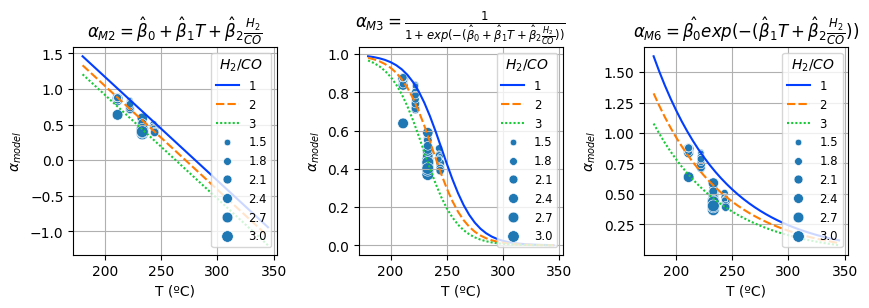

In [70]:
fig, ax = plt.subplots(1,3,figsize=(10,2.7))
plt.subplots_adjust(hspace=0.8, wspace = 0.4)
sns.lineplot(x='T (ºC)', y='value',
             data=alpha_best_models[['T (ºC)', '$H_2/CO$',
                                    'alpha_model_2',
                                    ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
             style = '$H_2/CO$',
             hue = '$H_2/CO$',
             palette = "bright",
             ax = ax[0])
ax[0].set_title(r'$\alpha_{M2} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}$')

sns.scatterplot(x='T (ºC)', y='alpha',
             data=data, 
             size = '$H_2/CO$',
             palette = "bright",
             legend = 'brief',
             ax = ax[0])

sns.lineplot(x='T (ºC)', y='value',
             data=alpha_best_models[['T (ºC)', '$H_2/CO$',
                                    'alpha_model_3',
                                    ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
             style = '$H_2/CO$',
             hue = '$H_2/CO$',
             palette = "bright",
             ax = ax[1])
ax[1].set_title(r'$\alpha_{M3} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))}$')

sns.scatterplot(x='T (ºC)', y='alpha',
             data=data, 
             size = '$H_2/CO$',
             palette = "bright",
             legend = 'brief',
             ax = ax[1])

sns.lineplot(x='T (ºC)', y='value',
             data=alpha_best_models[['T (ºC)', '$H_2/CO$',
                                    'alpha_model_6',
                                    ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
             style = '$H_2/CO$',
             hue = '$H_2/CO$',
             palette = "bright",
             ax = ax[2])
ax[2].set_title(r'$\alpha_{M6} = \hat{\beta_0} exp(-(\hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))$')

sns.scatterplot(x='T (ºC)', y='alpha',
             data=data, 
             size = '$H_2/CO$',
             palette = "bright",
             legend = 'brief',
             ax = ax[2])

for i in range(3):
    ax[i].grid('both')
    ax[i].set_xlabel('T (ºC)')
    ax[i].set_ylabel(r'$\alpha_{model}$')
    ax[i].legend(title = '$H_2/CO$', ncols = 1, fontsize='small')
# plt.grid('both')
# plt.ylim(0,None)
# # plt.xlim(0,80)
# plt.legend(title = '$H_2/CO$', bbox_to_anchor=(1.02, 1))
# plt.ylabel(r'$\alpha$')
# plt.xlabel('$T$ (K)')
fig_name = 'alpha_models.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [71]:
# visualizing the oleffin/paraffin ratio
OL_P = data[['T_R_K', '$H_2/CO$',
        'OL_P_2', 'OL_P_7', 'OL_P_8', 'OL_P_9', 'OL_P_10', 'OL_P_11', 'OL_P_12', 'OL_P_13', 'OL_P_14',
        'OL_P_15', 'OL_P_16', 'OL_P_17', 'OL_P_18'
        ]].melt(id_vars = ['T_R_K', '$H_2/CO$'],
               var_name = 'n_C', value_name = 'OL_P_ratio')
OL_P = OL_P.replace([np.inf, -np.inf], np.nan)
OL_P = OL_P.dropna()
OL_P = OL_P.replace({
    'OL_P_2': 2, 
    'OL_P_7':7,
    'OL_P_8':8,
    'OL_P_9':9,
    'OL_P_10':10,
    'OL_P_11':11,
    'OL_P_12':12,
    'OL_P_13':13,
    'OL_P_14':14,
    'OL_P_15':15,
    'OL_P_16':16,
    'OL_P_17':17,
    'OL_P_18':18,
}
                   ).infer_objects(copy=False)
OL_P

/tmp/ipykernel_11087/526032694.py:24: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ).infer_objects(copy=False)


,T_R_K,$H_2/CO$,n_C,OL_P_ratio
0,506.15,3.087668,2,0.190313
1,506.15,3.087668,2,0.190313
2,506.15,3.087668,2,0.190313
3,506.15,3.087668,2,0.227040
4,506.15,3.087668,2,0.269610
...,...,...,...,...
1152,484.15,1.824237,18,0.000000
1153,484.15,1.824237,18,0.000000
1154,506.15,3.107949,18,0.000000
1155,506.15,3.107949,18,0.000000


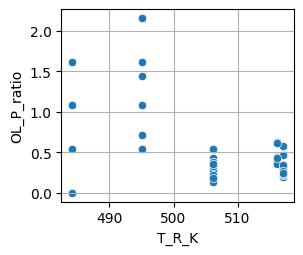

In [72]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='T_R_K', y='OL_P_ratio',
             data=OL_P.loc[OL_P['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

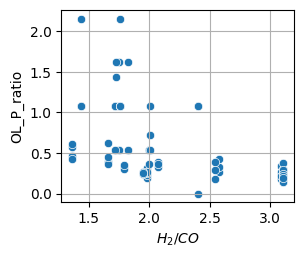

In [73]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='$H_2/CO$', y='OL_P_ratio',
             data=OL_P.loc[OL_P['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

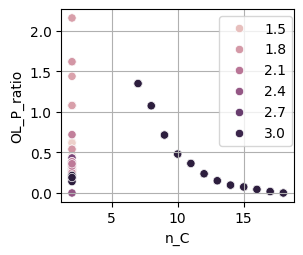

In [74]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='n_C', y='OL_P_ratio',
             data=OL_P,
            hue = '$H_2/CO$',
            ax = ax)

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

In [75]:
kinetic_data = data.loc[data['CINÉTICA'] == 1.0].reset_index()
plot_data = data.loc[(data['DESATIVAÇÃO'] == 1.0) | (data['CINÉTICA'] == 1.0)].reset_index()
deactivation_data = data.loc[data['DESATIVAÇÃO'] == 1.0].reset_index()
data_mass_T = pd.read_excel('data_mass_T.ods')
data_mass_T = data_mass_T.loc[data_mass_T['MASS_T'] == 1.0].reset_index()
data_mass_T['-r_CO'] = -(data_mass_T['F_CO_s_mol_s'] - data_mass_T['F_CO_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['-r_H2'] = -(data_mass_T['F_H2_s_mol_s'] - data_mass_T['F_H2_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['T_R_C'] = data_mass_T['T_R_K'] - 273.15

In [76]:
from sklearn.model_selection import train_test_split

fitting_data, test_data = train_test_split(kinetic_data, test_size=0.4, random_state=105)
fitting_data = fitting_data.reset_index()
test_data = test_data.reset_index()

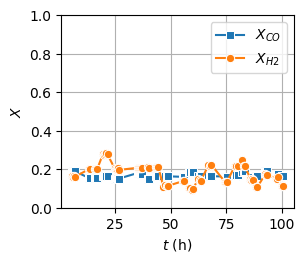

In [77]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x='t_h', y='X_CO',
             data=kinetic_data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.lineplot(x='t_h', y='X_H2',
             data=kinetic_data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_kinetics.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

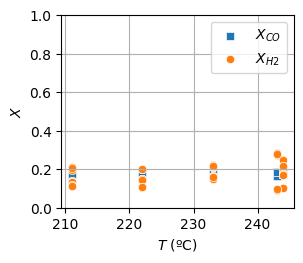

In [78]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='T_R_C', y='X_CO',
             data=kinetic_data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.scatterplot(x='T_R_C', y='X_H2',
             data=kinetic_data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$X$')
# fig_name = 'X_kinetics.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

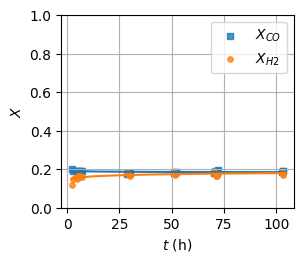

In [79]:
fig, ax = plt.subplots(figsize=(3,2.5))
line_w = 1.5
scatter_s = 15
sns.regplot(x='t_h', y='X_CO',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 's', label = '$X_{CO}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})
sns.regplot(x='t_h', y='X_H2',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 'o', label = '$X_{H2}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})

plt.grid('both')
plt.legend()
plt.ylim(0,1)
# plt.xlim(0,80)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_deactivation.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

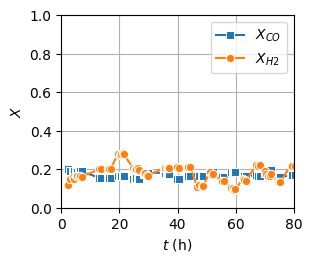

In [80]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x='t_h', y='X_CO',
             data=plot_data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.lineplot(x='t_h', y='X_H2',
             data=plot_data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(0,1)
plt.xlim(0,80)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_all_kinetic_test.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

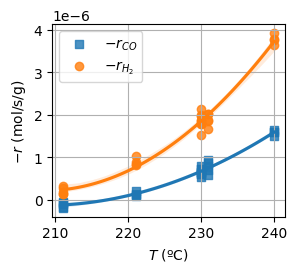

In [81]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.lineplot(x='T_R_C', y='-r_CO',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_CO',
             data=data_mass_T, ax = ax, marker = 's', label = '$-r_{CO}$', order = 2)
# sns.lineplot(x='T_R_C', y='-r_H2',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_H2',
             data=data_mass_T, ax = ax, marker = 'o', label = '$-r_{H_2}$', order = 2)

plt.grid('both')
plt.legend()
# plt.ylim(0,None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$-r$ (mol/s/g)')
fig_name = 'T_vs_r_mass_T.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [82]:
# plotting the K_Cs

In [83]:
# ignore K_C outliers
data_K_C = data[(np.abs(stats.zscore(data[['K_C2', 'K_C3']])) < 1.5).all(axis=1)].copy()

In [84]:
from scipy.optimize import curve_fit

def sigmoid(x, L, x0, k, b):
    y = b + L / (1 + np.exp(-k*(x - x0)))
    return y

x_KC = data_K_C[['T_R_K']].values.flatten()

In [85]:
y_K_C2 = data_K_C[['K_C2']].values.flatten()
p0_K_C2 = [max(y_K_C2) - min(y_K_C2), np.median(x_KC), 0.1, min(y_K_C2)]

popt_K_C2, pcov_K_C2 = curve_fit(sigmoid, x_KC, y_K_C2, p0_K_C2, method='dogbox')
# Extract the optimized parameters
fit_L_K_C2, fit_x0_K_C2, fit_k_K_C2, fit_b_K_C2 = popt_K_C2

# Generate points for the fitted curve
x_plot_KC = np.linspace(min(x_KC), max(x_KC), 100)
y_fit_K_C2 = sigmoid(x_plot_KC, fit_L_K_C2, fit_x0_K_C2, fit_k_K_C2, fit_b_K_C2)

# plt.figure(figsize=(8, 5))
# plt.scatter(x_KC, y_K_C2, label='Data points')
# plt.plot(x_plot_KC, y_fit_K_C2, color='red', linewidth=2, label='Fitted Sigmoid Curve')
# plt.title('Sigmoid Curve Fitting with SciPy')
# plt.xlabel('X values')
# plt.ylabel('Y values')
# plt.legend()
# plt.show()

print(f"Optimized Parameters: L={fit_L_K_C2:.3f}, x0={fit_x0_K_C2:.3f}, k={fit_k_K_C2:.3f}, b={fit_b_K_C2:.3f}")

Optimized Parameters: L=12.877, x0=495.969, k=-0.267, b=1.942


In [86]:
y_K_C3 = data_K_C[['K_C3']].values.flatten()
p0_K_C3 = [max(y_K_C3) - min(y_K_C3), np.median(x_KC), 0.1, min(y_K_C3)]

popt_K_C3, pcov_K_C3 = curve_fit(sigmoid, x_KC, y_K_C3, p0_K_C3, method='dogbox')
# Extract the optimized parameters
fit_L_K_C3, fit_x0_K_C3, fit_k_K_C3, fit_b_K_C3 = popt_K_C3

# Generate points for the fitted curve
x_plot_KC = np.linspace(min(x_KC), max(x_KC), 100)
y_fit_K_C3 = sigmoid(x_plot_KC, fit_L_K_C3, fit_x0_K_C3, fit_k_K_C3, fit_b_K_C3)

# plt.figure(figsize=(8, 5))
# plt.scatter(x_KC, y_K_C3, label='Data points')
# plt.plot(x_plot_KC, y_fit_K_C3, color='red', linewidth=2, label='Fitted Sigmoid Curve')
# plt.title('Sigmoid Curve Fitting with SciPy')
# plt.xlabel('X values')
# plt.ylabel('Y values')
# plt.legend()
# plt.show()

print(f"Optimized Parameters: L={fit_L_K_C3:.3f}, x0={fit_x0_K_C3:.3f}, k={fit_k_K_C3:.3f}, b={fit_b_K_C3:.3f}")

Optimized Parameters: L=5.167, x0=496.098, k=-0.557, b=-0.366


In [87]:
data_K_C_pred = pd.DataFrame()
data_K_C_pred['T_R_K'] = x_plot_KC
data_K_C_pred['K_C2_pred'] = y_fit_K_C2
data_K_C_pred['K_C3_pred'] = y_fit_K_C3

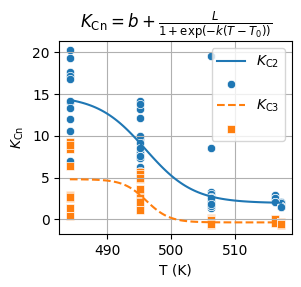

In [88]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(x='T_R_K', y='K_C2_pred',
             data=data_K_C_pred,
            ax = ax, label = '$K_\mathrm{C2}$', linestyle = '-')
sns.scatterplot(x='T_R_K', y='K_C2',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 'o')
sns.lineplot(x='T_R_K', y='K_C3_pred',
             data=data_K_C_pred,
            ax = ax, label = '$K_\mathrm{C3}$', linestyle = '--')
sns.scatterplot(x='T_R_K', y='K_C3',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel(r'$K_{\mathrm{Cn}}$')
plt.xlabel('T (K)')
plt.title(r'$K_\mathrm{Cn} = b + \frac{L}{1 + \mathrm{exp}( - k (T - T_0) )}$')
# plt.ylim(0,25)
fig_name = 'K_C_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

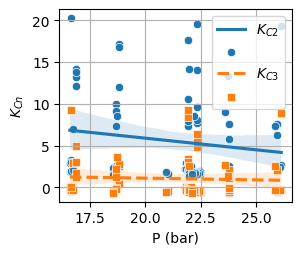

In [89]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.regplot(x='P (bar)', y='K_C2',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C2}$', line_kws = {'linestyle': '-'})
sns.scatterplot(x='P (bar)', y='K_C2',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 'o')
sns.regplot(x='P (bar)', y='K_C3',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C3}$', line_kws = {'linestyle': '--'})
sns.scatterplot(x='P (bar)', y='K_C3',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel('$K_{Cn}$')
plt.xlabel('P (bar)')
# plt.ylim(0,25)
fig_name = 'K_C_vs_P.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

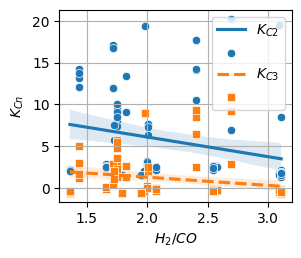

In [90]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.regplot(x='$H_2/CO$', y='K_C2',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C2}$', line_kws = {'linestyle': '-'})
sns.scatterplot(x='$H_2/CO$', y='K_C2',
             data=data_K_C,
#             hue = '$H_2/CO$',
#             size = '$H_2/CO$',
            ax = ax, label = ' ', marker = 'o')
sns.regplot(x='$H_2/CO$', y='K_C3',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C3}$', line_kws = {'linestyle': '--'})
sns.scatterplot(x='$H_2/CO$', y='K_C3',
             data=data_K_C,
#             hue = '$H_2/CO$',
#             size = '$H_2/CO$',
            ax = ax, label = ' ', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel('$K_{Cn}$')
plt.xlabel('$H_2/CO$')
# plt.ylim(0,25)
fig_name = 'K_C_vs_H2_CO.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [91]:
y_n = data_ASF_F[['y1', 'y2', 'y3', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
       'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
       'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33', 'y34',
       'y35']].copy()
y_n['index'] = data_ASF_F.index
y_n['T_R_K'] = data['T_R_K']
y_n['H2_CO'] = data['F_H2_e_mol_s'] / data['F_CO_e_mol_s']
y_n

,y1,y2,y3,y7,y8,y9,y10,y11,y12,y13,...,y29,y30,y31,y32,y33,y34,y35,index,T_R_K,H2_CO
38,0.587096,0.053737,0.166383,0.017967,0.020733,0.016327,0.016033,0.013793,0.012681,0.011420,...,0.000615,0.000423,0.000263,0.000255,0.000215,0.000182,0.000055,38,506.15,3.087668
39,0.577182,0.051571,0.165185,0.019205,0.022161,0.017452,0.017138,0.014743,0.013555,0.012206,...,0.000657,0.000452,0.000281,0.000273,0.000229,0.000195,0.000059,39,506.15,3.087668
40,0.578509,0.050488,0.161714,0.019506,0.022508,0.017725,0.017406,0.014974,0.013767,0.012397,...,0.000668,0.000459,0.000285,0.000277,0.000233,0.000198,0.000060,40,506.15,3.087668
41,0.581229,0.059362,0.148530,0.019654,0.022679,0.017860,0.017538,0.015087,0.013871,0.012492,...,0.000673,0.000462,0.000288,0.000279,0.000235,0.000199,0.000061,41,506.15,3.087668
42,0.566127,0.050780,0.167422,0.020100,0.023194,0.018266,0.017937,0.015430,0.014187,0.012775,...,0.000688,0.000473,0.000294,0.000286,0.000240,0.000204,0.000062,42,506.15,3.087668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,0.156672,0.032596,0.067257,0.069291,0.079956,0.062966,0.061833,0.053192,0.048905,0.044040,...,0.002372,0.001630,0.001014,0.000985,0.000828,0.000703,0.000214,205,484.15,1.824237
206,0.160772,0.000000,0.000000,0.078216,0.090253,0.071076,0.069796,0.060043,0.055204,0.049712,...,0.002677,0.001840,0.001144,0.001112,0.000934,0.000794,0.000241,206,484.15,1.824237
210,0.567459,0.058743,0.174150,0.018607,0.021471,0.016908,0.016604,0.014284,0.013133,0.011826,...,0.000637,0.000438,0.000272,0.000264,0.000222,0.000189,0.000057,210,506.15,3.107949
211,0.608261,0.054490,0.145258,0.017893,0.020647,0.016260,0.015967,0.013736,0.012629,0.011373,...,0.000612,0.000421,0.000262,0.000254,0.000214,0.000182,0.000055,211,506.15,3.107949


In [92]:
y_n = y_n.melt(id_vars = ['T_R_K', 'H2_CO', 'index'],
               var_name = 'n_C', value_name = 'y_n_exp')
y_n['n_C'] = y_n['n_C'].str.replace('y', '').astype('int32')

In [93]:
betas_alpha = minimums_alpha.loc[minimums_alpha['model'] == 'model_3', 'params'].values[0]
betas_alpha

array([36.14991391, -0.06859762, -0.56477343])

In [94]:
y_n['alpha_pred'] = 1 / ( 1 + np.exp( - ( betas_alpha[0] 
                                          + betas_alpha[1] * y_n['T_R_K']
                                          + betas_alpha[2] * y_n['H2_CO']
                                        ) ) )

In [95]:
fit_L_K_C2, fit_x0_K_C2, fit_k_K_C2, fit_b_K_C2 = popt_K_C2


In [96]:
y_n['K_C2_pred'] = sigmoid(y_n[['T_R_K']], fit_L_K_C2, fit_x0_K_C2, fit_k_K_C2, fit_b_K_C2)

In [97]:
y_n['K_C3_pred'] = sigmoid(y_n[['T_R_K']], fit_L_K_C3, fit_x0_K_C3, fit_k_K_C3, fit_b_K_C3)

In [98]:
y_n_exponent = y_n.n_C - 1 + y_n.K_C2_pred * ( y_n.n_C == 2 ) + y_n.K_C3_pred * ( y_n.n_C == 3 )
y_n['y_n_pred'] = ( 1 - y_n['alpha_pred'] ) * y_n['alpha_pred'] ** y_n_exponent

In [99]:
# normalizing y_n_pred
y_n['y_n_pred'] = y_n['y_n_pred'] / y_n.groupby('index')['y_n_pred'].transform('sum')

In [100]:
y_n['y_n_pred_no_Kc'] = ( 1 - y_n['alpha_pred'] ) * y_n['alpha_pred'] ** ( y_n.n_C - 1 )

In [101]:
y_n

,T_R_K,H2_CO,index,n_C,y_n_exp,alpha_pred,K_C2_pred,K_C3_pred,y_n_pred,y_n_pred_no_Kc
0,506.15,3.087668,38,1,0.587096,0.421991,2.742234,-0.347162,7.754089e-01,5.780089e-01
1,506.15,3.087668,39,1,0.577182,0.421991,2.742234,-0.347162,7.754089e-01,5.780089e-01
2,506.15,3.087668,40,1,0.578509,0.421991,2.742234,-0.347162,7.754089e-01,5.780089e-01
3,506.15,3.087668,41,1,0.581229,0.421991,2.742234,-0.347162,7.754089e-01,5.780089e-01
4,506.15,3.087668,42,1,0.566127,0.421991,2.742234,-0.347162,7.754089e-01,5.780089e-01
...,...,...,...,...,...,...,...,...,...,...
2843,484.15,1.824237,205,35,0.000214,0.870805,14.290443,4.794612,1.878425e-03,1.170996e-03
2844,484.15,1.824237,206,35,0.000241,0.870805,14.290443,4.794612,1.878425e-03,1.170996e-03
2845,506.15,3.107949,210,35,0.000057,0.419200,2.742234,-0.347162,1.130315e-13,8.439948e-14
2846,506.15,3.107949,211,35,0.000055,0.419200,2.742234,-0.347162,1.130315e-13,8.439948e-14


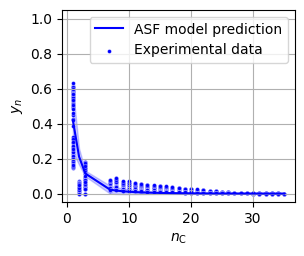

In [102]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=y_n, 
                x="n_C", 
                y="y_n_pred_no_Kc", 
                ax = ax,
                label = 'ASF model prediction',
                color = 'blue',
                errorbar=("sd", 1)
)
sns.scatterplot(
                data=y_n, 
                x="n_C", 
                y="y_n_exp", 
                ax = ax,
                label = 'Experimental data',
                color = 'blue', s = 8
)
plt.grid('both')
plt.ylabel('$y_n$')
plt.xlabel(r'$n_\mathrm{C}$')
# plt.yscale('log')
plt.ylim(-0.05,1.05)
fig_name = 'ASF_plot_no_K_Cn.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

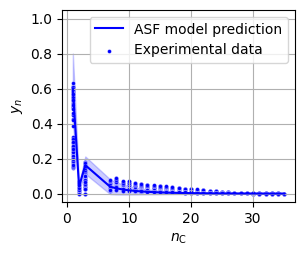

In [103]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=y_n, 
                x="n_C", 
                y="y_n_pred", 
                ax = ax,
                label = 'ASF model prediction',
                color = 'blue',
                errorbar=("sd", 1)
)
sns.scatterplot(
                data=y_n, 
                x="n_C", 
                y="y_n_exp", 
                ax = ax,
                label = 'Experimental data',
                color = 'blue', s = 8
)
plt.grid('both')
plt.ylabel('$y_n$')
plt.xlabel(r'$n_\mathrm{C}$')
# plt.yscale('log')
plt.ylim(-0.05,1.05)
fig_name = 'ASF_plot.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

In [135]:
H2_CO_data = data[['F_H2_e_mol_s', 'F_H2_s_mol_s', 'F_CO_e_mol_s', 'F_CO_s_mol_s']]

In [142]:
H2_CO_data.std()/H2_CO_data.mean()

F_H2_e_mol_s    0.192544
F_H2_s_mol_s    0.189860
F_CO_e_mol_s    0.182464
F_CO_s_mol_s    0.190257
dtype: float64